<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/00_Data_Loading_and_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1 실습: 시계열 데이터 불러오기 및 탐색
**Notebook:** `00_Data_Loading_and_Exploration.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 온라인 환경에서 시계열 데이터를 안전하게 불러옵니다.
2. `pandas` 데이터프레임의 구조와 인덱스를 확인합니다.
3. 시계열 데이터에서 왜 **Datetime Index**가 중요한지 이해합니다.
4. 종가(Close), 거래량(Volume), 수익률(Return)과 같은 기본 변수들을 생성합니다.
5. 시계열 플롯을 통해 추세(Trend), 충격(Shock), 변동성(Volatility)을 직관적으로 관찰합니다.
6. CSV 파일을 읽을 때 날짜 컬럼을 어떻게 처리하는지 익힙니다.

---

## 왜 이 실습이 중요한가?
시계열 분석은 모델링보다 먼저 **데이터를 시간 순서대로 올바르게 다루는 것**에서 시작합니다.  
시간 컬럼을 날짜형으로 바꾸고, 이를 인덱스로 설정하며, 그래프로 흐름을 읽는 과정은 이후의 모든 분석(정상성 검정, ARIMA, 머신러닝, 딥러닝)의 기초가 됩니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================
# pandas: 표 형태 데이터 처리
# numpy: 수치 계산
# matplotlib: 시각화
# warnings: 불필요한 경고 메시지 제어
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Notebook 환경에서 표를 보기 좋게 출력하기 위한 display 함수
from IPython.display import display


## 1. 온라인 환경 준비
이 실습은 **Google Colab**이나 **Jupyter Notebook**에서 바로 실행할 수 있도록 구성했습니다.

금융 데이터를 쉽게 가져오기 위해 `yfinance` 패키지를 사용합니다.  
만약 현재 환경에 설치되어 있지 않다면 자동으로 설치합니다.

> 참고  
> - Colab에서는 처음 한 번 설치가 필요할 수 있습니다.
> - 설치 후에는 바로 아래 셀에서 데이터를 다운로드할 수 있습니다.


In [2]:
# ============================================
# 2. yfinance 설치 및 임포트
# ============================================
# Yahoo Finance에서 주가 데이터를 가져오기 위한 패키지입니다.
# try-except 구조를 사용하면,
# - 이미 설치되어 있으면 바로 import
# - 설치되어 있지 않으면 pip로 설치 후 import
# ============================================

try:
    import yfinance as yf
    print('yfinance가 이미 설치되어 있습니다.')
except ImportError:
    print('yfinance가 설치되어 있지 않아 지금 설치합니다...')
    !pip -q install yfinance
    import yfinance as yf
    print('yfinance 설치가 완료되었습니다.')


yfinance가 이미 설치되어 있습니다.


## 2. 시각화 기본 설정
시계열 분석에서는 그래프를 매우 자주 사용합니다.  
따라서 실습 초기에 그래프 스타일과 크기를 미리 설정해두면 편리합니다.

이번 버전에서는 **그래프 안의 제목, 축 이름, 범례는 모두 영어로 출력**합니다.  
이렇게 하면 Colab에서 한글 폰트 문제 없이 안정적으로 시각화할 수 있습니다.


In [3]:
# ============================================
# 3. 시각화 기본 설정
# ============================================
# 그래프 텍스트는 모두 영어로 넣을 것이므로,
# 별도의 한글 폰트 설정 없이도 Colab에서 안정적으로 실행됩니다.
# ============================================

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.unicode_minus'] = False


## 3. 온라인에서 금융 시계열 데이터 불러오기
이번 실습에서는 예시로 **테슬라(TSLA)** 의 일별 주가 데이터를 사용합니다.

우리가 받고 싶은 핵심 컬럼은 보통 다음과 같습니다.

- **Open**: 시가
- **High**: 고가
- **Low**: 저가
- **Close**: 종가
- **Volume**: 거래량

시계열 분석에서 중요한 점은, 데이터를 단순한 표로 보는 것이 아니라  
**시간 순서가 있는 데이터**로 읽는 것입니다.


In [4]:
ticker = 'TSLA'
start_date = '2020-01-01'
end_date = '2023-12-31'

tsla_df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

print('데이터 다운로드 완료')
print(f'종목: {ticker}')
print(f'데이터 크기(shape): {tsla_df.shape}')

display(tsla_df.head())


데이터 다운로드 완료
종목: TSLA
데이터 크기(shape): (1006, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2020-01-02,28.684000,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,32.809334,33.232666,31.215334,31.580000,467164500


## 4. 데이터 구조 확인하기
시계열 분석에서 데이터를 받으면 가장 먼저 해야 할 일은 다음 세 가지입니다.

1. **행과 열의 크기 확인**
2. **컬럼 이름 확인**
3. **인덱스가 날짜형인지 확인**

특히 마지막이 중요합니다.  
시계열 데이터는 보통 `DatetimeIndex`를 가져야 시간 기반 슬라이싱과 시각화가 자연스럽게 작동합니다.


In [5]:
print('===== 데이터 정보(info) =====')
print(tsla_df.info())

print('\n===== 컬럼 이름 =====')
print(tsla_df.columns.tolist())

print('\n===== 인덱스 타입 =====')
print(type(tsla_df.index))


===== 데이터 정보(info) =====
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, TSLA)  1006 non-null   float64
 1   (Close, TSLA)      1006 non-null   float64
 2   (High, TSLA)       1006 non-null   float64
 3   (Low, TSLA)        1006 non-null   float64
 4   (Open, TSLA)       1006 non-null   float64
 5   (Volume, TSLA)     1006 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 55.0 KB
None

===== 컬럼 이름 =====
[('Adj Close', 'TSLA'), ('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]

===== 인덱스 타입 =====
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## 5. Datetime Index의 중요성
시계열 데이터는 단순한 행 번호가 아니라 **시간을 인덱스로 가지는 구조**여야 합니다.

이렇게 해야 특정 연도, 특정 월, 날짜 범위 선택이 쉬워지고,
리샘플링이나 롤링 통계 계산도 자연스럽게 수행할 수 있습니다.


In [6]:
tsla_march_2020 = tsla_df.loc['2020-03']

print('2020년 3월 데이터 개수:', len(tsla_march_2020))
display(tsla_march_2020.head())


2020년 3월 데이터 개수: 22


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2020-03-02,49.574669,49.574669,49.579334,45.778000,47.417332,302925000
2020-03-03,49.700668,49.700668,53.798668,47.740665,53.666668,386760000
2020-03-04,49.966667,49.966667,51.101334,48.315334,50.930668,225735000
2020-03-05,48.302666,48.302666,49.716667,47.871334,48.251331,162790500
2020-03-06,46.898666,46.898666,47.133331,45.618000,46.000000,189943500


## 6. 시계열 데이터의 가장 기본적인 시각화
시계열 분석의 첫 번째 진단 도구는 **선 그래프(line plot)** 입니다.

종가(Close)를 그리면 다음과 같은 질문을 던질 수 있습니다.

- 장기적으로 상승 추세가 있는가?
- 특정 시점에 급락 또는 급등이 있었는가?
- 변동성이 시기마다 달라지는가?


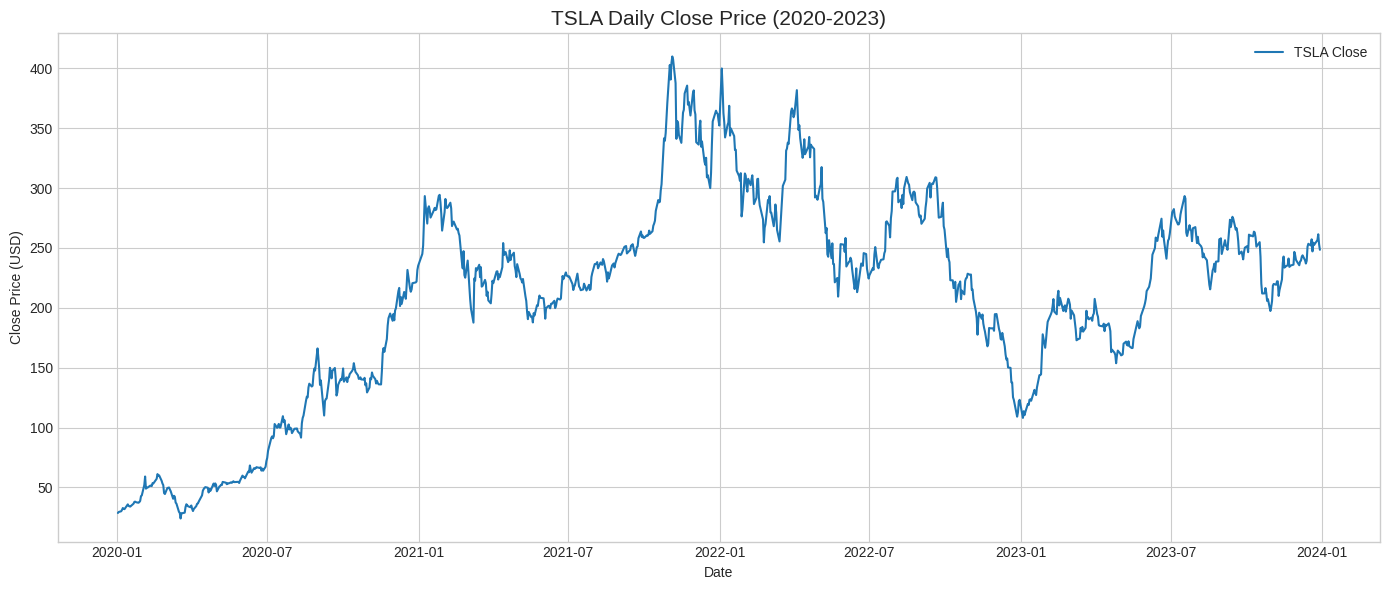

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(tsla_df.index, tsla_df['Close'], label='TSLA Close', linewidth=1.5)

plt.title('TSLA Daily Close Price (2020-2023)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()


## 7. 거래량(Volume)도 함께 보기
주가만 보는 것보다 거래량을 함께 보면 더 많은 정보를 얻을 수 있습니다.

예를 들어,
- 가격이 급등할 때 거래량도 함께 급증했는가?
- 충격 시점에 거래량이 비정상적으로 커졌는가?


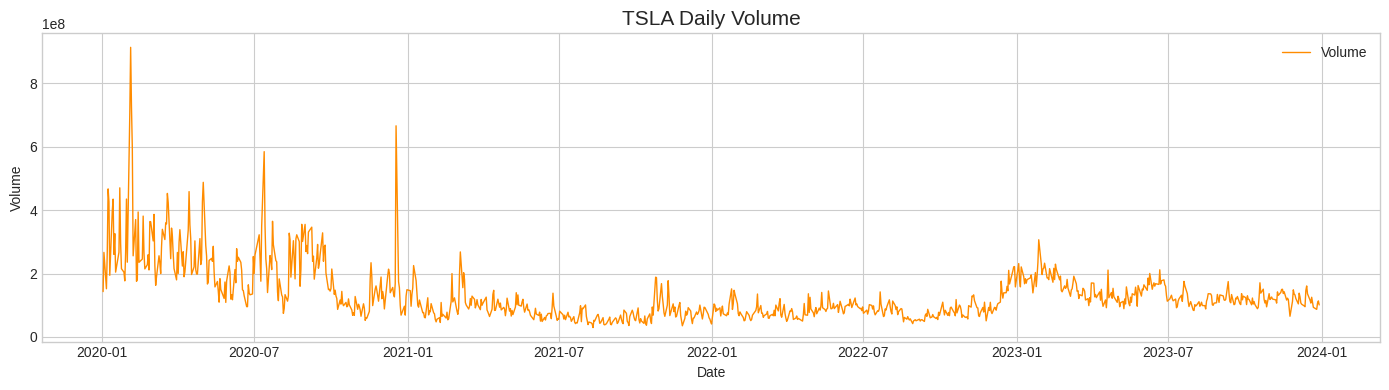

In [8]:
plt.figure(figsize=(14, 4))
plt.plot(tsla_df.index, tsla_df['Volume'], color='darkorange', label='Volume', linewidth=1)

plt.title('TSLA Daily Volume', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.tight_layout()
plt.show()


## 8. 수익률(Return) 변수 만들기
금융 시계열에서는 종가 자체보다 **수익률(Return)** 을 분석하는 경우가 많습니다.

여기서는 가장 간단한 **일별 단순 수익률**과 **로그 수익률**을 만들어 보겠습니다.


In [9]:
tsla_df['Simple_Return'] = tsla_df['Close'].pct_change()
tsla_df['Log_Return'] = np.log(tsla_df['Close'] / tsla_df['Close'].shift(1))

display(tsla_df[['Close', 'Simple_Return', 'Log_Return']].head(10))


Price,Close,Simple_Return,Log_Return
Ticker,TSLA,,
Date,,,
2020-01-02,28.684000,NaN,NaN
2020-01-03,29.534000,0.029633,0.029203
2020-01-06,30.102667,0.019255,0.019072
2020-01-07,31.270666,0.038801,0.038067
2020-01-08,32.809334,0.049205,0.048033
2020-01-09,32.089333,-0.021945,-0.022189
2020-01-10,31.876667,-0.006627,-0.006649
2020-01-13,34.990665,0.097689,0.093207


## 9. 수익률 시각화
가격 그래프와 수익률 그래프는 매우 다르게 보입니다.

- 가격은 장기 추세를 보일 수 있음
- 수익률은 대체로 0 근처에서 위아래로 진동함
- 특정 위기 구간에서는 수익률의 진폭이 커질 수 있음


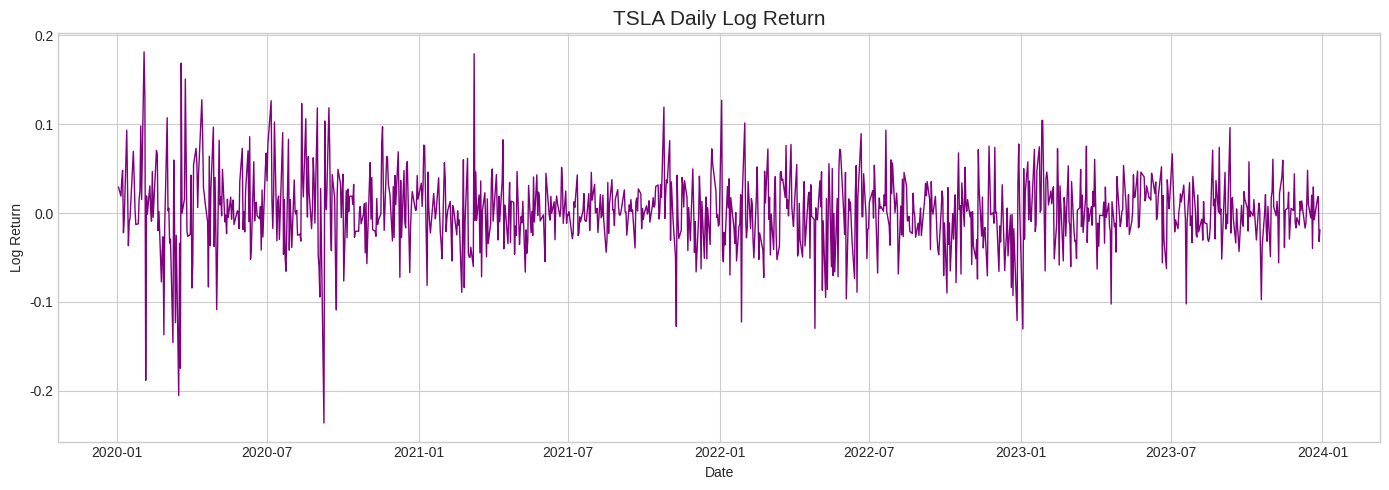

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(tsla_df.index, tsla_df['Log_Return'], color='purple', linewidth=1)

plt.title('TSLA Daily Log Return', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.tight_layout()
plt.show()


## 10. 기초 통계량 확인
시계열 분석에서는 그래프뿐 아니라 요약 통계도 함께 봐야 합니다.


In [11]:
summary_stats = tsla_df[['Close', 'Volume', 'Simple_Return', 'Log_Return']].describe()
display(summary_stats)


Price,Close,Volume,Simple_Return,Log_Return
Ticker,TSLA,TSLA,,
count,1006.000000,1.006000e+03,1005.000000,1005.000000
mean,209.126371,1.332264e+08,0.003070,0.002148
std,85.797682,8.862913e+07,0.042902,0.042906
min,24.081333,2.940180e+07,-0.210628,-0.236518
25%,160.210003,7.707188e+07,-0.020062,-0.020266
50%,223.489998,1.071037e+08,0.002170,0.002168
75%,262.967491,1.578315e+08,0.023880,0.023599
max,409.970001,9.140820e+08,0.198949,0.181445


## 11. 이동평균(Moving Average)로 추세를 부드럽게 보기
원시 시계열은 노이즈가 커서 흐름을 읽기 어려울 수 있습니다.
이동평균을 함께 그리면 단기 변동을 완화한 부드러운 흐름을 볼 수 있습니다.


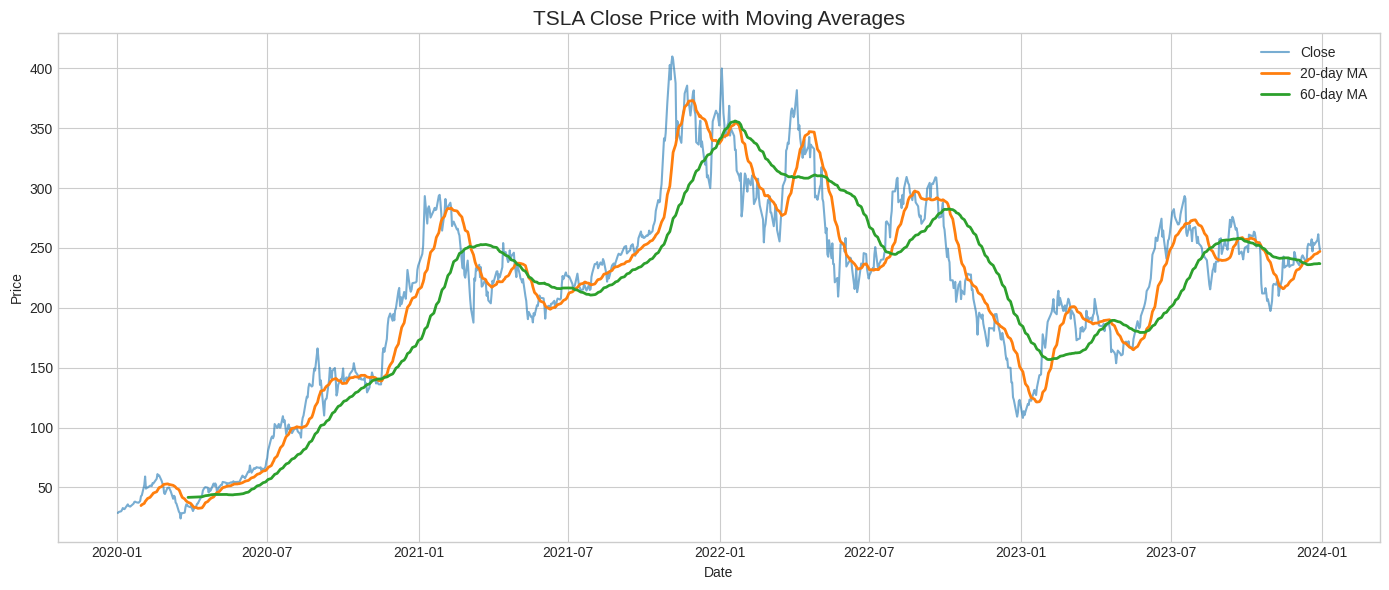

In [12]:
tsla_df['MA20'] = tsla_df['Close'].rolling(window=20).mean()
tsla_df['MA60'] = tsla_df['Close'].rolling(window=60).mean()

plt.figure(figsize=(14, 6))
plt.plot(tsla_df.index, tsla_df['Close'], label='Close', alpha=0.6)
plt.plot(tsla_df.index, tsla_df['MA20'], label='20-day MA', linewidth=2)
plt.plot(tsla_df.index, tsla_df['MA60'], label='60-day MA', linewidth=2)

plt.title('TSLA Close Price with Moving Averages', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


## 12. 온라인 환경에서도 가능한 CSV 실습
실무에서는 API가 아니라 CSV 파일을 직접 받는 경우가 많습니다.  
하지만 강의 환경에서는 로컬 파일이 없을 수도 있으므로, 여기서는 **Notebook 안에서 직접 작은 CSV 문자열을 만들어** 연습하겠습니다.


In [13]:
from io import StringIO

csv_text = '''
date,PM10,PM25
2024-01-01 00:00,42,21
2024-01-01 01:00,40,20
2024-01-01 02:00,39,19
2024-01-01 03:00,41,20
2024-01-01 04:00,45,22
2024-01-01 05:00,50,25
'''

sample_air_df = pd.read_csv(StringIO(csv_text), parse_dates=['date'])
sample_air_df.set_index('date', inplace=True)
sample_air_df.sort_index(inplace=True)

display(sample_air_df)
print('인덱스 타입:', type(sample_air_df.index))


,PM10,PM25
date,,
2024-01-01 00:00:00,42,21
2024-01-01 01:00:00,40,20
2024-01-01 02:00:00,39,19
2024-01-01 03:00:00,41,20
2024-01-01 04:00:00,45,22
2024-01-01 05:00:00,50,25


인덱스 타입: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## 13. CSV 기반 시계열도 그래프로 그려보기
작은 예시라도 날짜형 변환, 인덱스 지정, 시간순 정렬, 선 그래프 확인의 네 단계를 항상 수행하는 습관이 중요합니다.


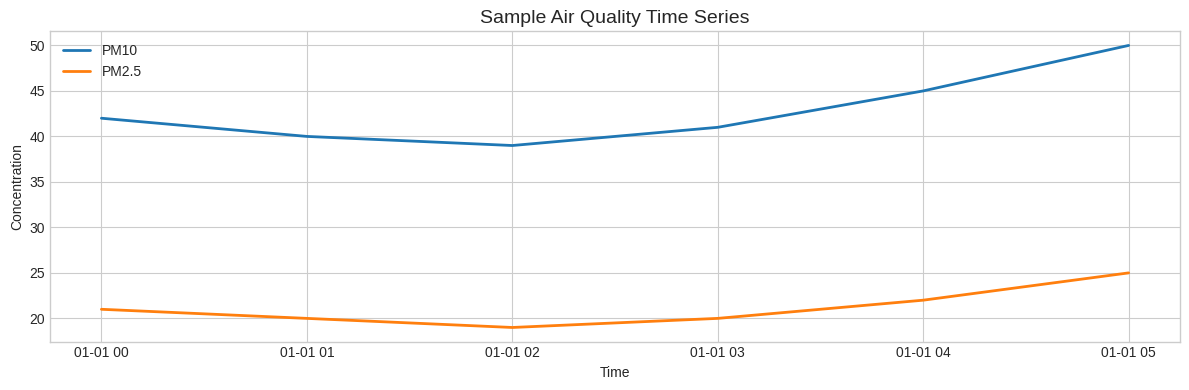

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(sample_air_df.index, sample_air_df['PM10'], label='PM10', linewidth=2)
plt.plot(sample_air_df.index, sample_air_df['PM25'], label='PM2.5', linewidth=2)

plt.title('Sample Air Quality Time Series', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.tight_layout()
plt.show()


## 14. Colab에서 사용자가 직접 CSV 업로드하기 (선택 실습)
만약 수강생이 자신의 CSV 파일을 가지고 있다면, Colab에서는 업로드 기능을 사용할 수 있습니다.
아래 코드는 **선택 실습**입니다.


In [15]:
"""
from google.colab import files
uploaded = files.upload()

df_uploaded = pd.read_csv('my_data.csv', parse_dates=['date'])
df_uploaded.set_index('date', inplace=True)
df_uploaded.sort_index(inplace=True)

display(df_uploaded.head())
"""
print('선택 실습용 Colab 업로드 템플릿입니다.')


선택 실습용 Colab 업로드 템플릿입니다.


## 15. 실습 정리
이번 실습에서 우리는 시계열 데이터의 가장 기초적인 처리 과정을 수행했습니다.

### 오늘 확인한 핵심
- 시계열 데이터는 **시간 순서**가 중요하다.
- 날짜 컬럼은 반드시 **Datetime 형식**으로 다루는 것이 좋다.
- **Datetime Index**는 시계열 분석의 출발점이다.
- 그래프를 먼저 그려야 추세, 충격, 변동성을 읽을 수 있다.
- 금융 데이터에서는 가격뿐 아니라 **수익률**도 자주 사용한다.
- CSV 파일을 읽을 때도 날짜 파싱과 인덱스 설정이 핵심이다.


## 16. 연습문제 (Exercises)

1. 테슬라 대신 애플(AAPL) 또는 마이크로소프트(MSFT) 데이터를 불러와 같은 그래프를 그려보시오.
2. `Close` 대신 `Adj Close`를 사용했을 때 그래프가 어떻게 달라지는지 비교해 보시오.
3. `rolling(window=5).mean()`과 `rolling(window=30).mean()`을 각각 계산하여 짧은 이동평균과 긴 이동평균의 차이를 설명해 보시오.
4. 샘플 CSV 데이터에서 `PM10`의 2시점 이동평균을 계산해 보시오.
5. 가격 그래프와 로그 수익률 그래프를 비교한 뒤, 어느 쪽이 더 안정적으로 보이는지 자신의 언어로 설명해 보시오.
